In [14]:
!pip3 install numpy matplotlib control

In [15]:
import control
import matplotlib.pyplot as plt
import numpy as np


In [16]:
# 1. Define the Transfer Function G(s) = 1 / (s^4 + 2s^3 + 3s^2 + 2s)
# Numerator coefficients: 1
# Denominator coefficients: s^4 (1), s^3 (2), s^2 (3), s^1 (2), s^0 (0)
num = [1]
den = [1, 2, 3, 2, 0]
sys = control.TransferFunction(num, den)


In [19]:
# 2. Calculate Performance Metrics
poles = control.poles(sys)
zeros = control.zeros(sys)
gm, pm, wg, wp = control.margin(sys)

print("--- System Definition and Metrics ---")
print(f"Transfer Function:\n{sys}")
print(f"Poles: {poles}")
print(f"Zeros: {zeros}")
print(f"Gain Margin (GM): {gm:.2f} (inf if stable/no phase cross)")
print(f"Phase Margin (PM): {pm:.2f} deg (at {wp:.2f} rad/s)")
print(f"Gain Crossover Frequency: {wg:.2f} rad/s")

--- System Definition and Metrics ---
Transfer Function:
<TransferFunction>: sys[12]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

              1
  -------------------------
  s^4 + 2 s^3 + 3 s^2 + 2 s
Poles: [-0.5+1.32287566j -0.5-1.32287566j -1. +0.j          0. +0.j        ]
Zeros: []
Gain Margin (GM): 2.00 (inf if stable/no phase cross)
Phase Margin (PM): 48.21 deg (at 0.49 rad/s)
Gain Crossover Frequency: 1.00 rad/s


In [20]:
# 3. Transient Analysis: Step Response
# Note: The system has a pole at s=0, meaning the step response will exhibit 
# an integrating (non-settling) behavior over time.
time, response = control.step_response(sys)


In [21]:
# 4. Visualization and Plotting
fig = plt.figure(figsize=(14, 10))

<Figure size 1400x1000 with 0 Axes>

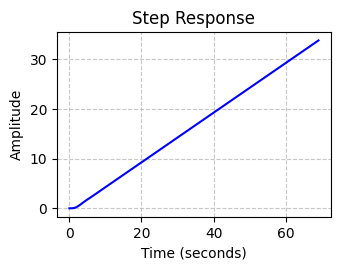

In [28]:
# Subplot 1: Step Response
plt.subplot(2, 2, 1)
plt.plot(time, response, color='blue', linewidth=1.5)
plt.title('Step Response')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

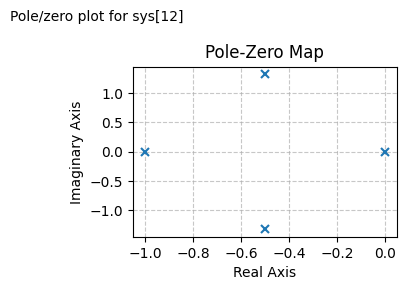

In [29]:
# Subplot 2: Pole-Zero Map
plt.subplot(2, 2, 2)
control.pole_zero_plot(sys)
plt.title('Pole-Zero Map')
plt.xlabel('Real Axis')
plt.ylabel('Imaginary Axis')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


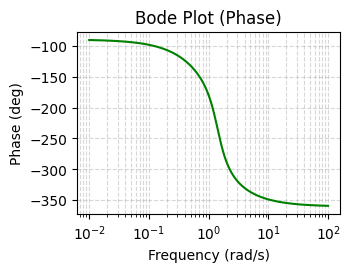

In [ ]:
# Subplot 3: Bode Plot Phase
plt.subplot(2, 2, 4)
plt.semilogx(omega, np.rad2deg(phase), color='green')
plt.title('Bode Plot (Phase)')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Phase (deg)')
plt.grid(True, which="both", linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

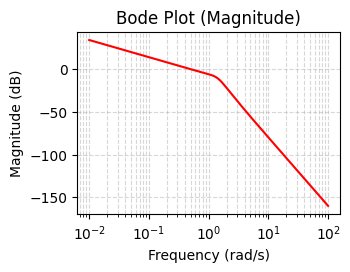

In [31]:
# Subplot 4: Bode Plot Magnitude
mag, phase, omega = control.bode(sys, omega_limits=[0.01, 100], plot=False)
plt.subplot(2, 2, 2)
plt.semilogx(omega, 20 * np.log10(mag), color='red')
plt.title('Bode Plot (Magnitude)')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Magnitude (dB)')
plt.grid(True, which="both", linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
